<a href="https://colab.research.google.com/github/HarryKmK13/Data-Mineing-and-analytics-26/blob/main/Khant_KyawMin_Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DMA Fall 2026



In [2]:
NAME = "Kyaw Min Khant"

---

# Lab 3: Decision Trees

**Please read the following instructions very carefully**

## Working on the assignment / FAQs
- **Always use the seed/random_state as *42* wherever applicable** (This is to ensure repeatability in answers, across students and coding environments)
- Questions can be either autograded and manually graded.
- The type of question and the points they carry are indicated in each question cell
- An autograded question has 3 cells
     - **Question cell** : Read only cell containing the question
     - **Code Cell** : This is where you write the code
     - **Grading cell** : This is where the grading occurs, and **you are required not to edit this cell**
- Manually graded questions only have the question and code cells. **All manually graded questions are explicitly stated**
- To avoid any ambiguity, each question also specifies what *value* must be set. Note that these are dummy values and not the answers
- If an autograded question has multiple answers (due to differences in handling NaNs, zeros etc.), all answers will be considered.
- Most assignments have bonus questions for extra credit, do try them out!
- You can delete the `raise NotImplementedError()` for all questions.
- **Submitting the assignment** : Download the '.ipynb' and '.pdf' files from Colab and upload them to bcourses. Do not delete any outputs from cells before submitting.
- That's about it. Happy coding!


## About the dataset
This assignment uses a dataset obtained from the JSE Data Archive that contains biological and self-reported activity traits of a sample of college students at a single university uploaded in 2013. The study associated with these data focused on exploring if a correspondence exists between eye color and other traits. You will be using gender as the target/label in this lab.

FEATURE DESCRIPTIONS:
- Color (Blue, Brown, Green, Hazel, Other)
- Age (in years)
- YearinSchool (First, Second, Third, Fourth, Other)
- Height (in inches)
- Miles (distance from home town of student to Ames, IA)
- Brothers (number of brothers)
- Sisters (number of sisters)
- CompTime (number of hours spent on computer per week)
- Exercise (whether the student exercises Yes or No)
- ExerTime (number of hours spent exercising per week)
- MusicCDs (number of music CDs student owns)
- PlayGames (number of hours spent playing games per week)
- WatchTV (number of hours spent watching TV per week

Background Information on the dataset: http://jse.amstat.org/v21n2/froelich/eyecolorgender.txt

In [3]:
!pip install gdown
from collections import Counter, defaultdict
from itertools import combinations
import pandas as pd
import numpy as np
import operator
import math
import itertools
from sklearn.feature_extraction import DictVectorizer
from sklearn import preprocessing, tree
import matplotlib.pyplot as plt
import gdown


# Download eye_color.csv
file_id = "1XkKBFGDu13sopGayWGz3qV9pIJgfPikD"
url = f"https://drive.google.com/uc?id={file_id}"
output = 'eye_color.csv'
gdown.download(url, output, quiet=False)


df = pd.read_csv('eye_color.csv')
# remove NA's and reset the index
df = df.dropna(axis=0, how='any', subset=None, inplace=False)
df = df.reset_index(drop=True)

df.head()

Downloading...
From: https://drive.google.com/uc?id=1XkKBFGDu13sopGayWGz3qV9pIJgfPikD
To: /content/eye_color.csv
100%|██████████| 102k/102k [00:00<00:00, 19.5MB/s]


,gender,age,year,eyecolor,height,miles,brothers,sisters,computertime,exercise,exercisehours,musiccds,playgames,watchtv
0,female,18,first,hazel,68.0,195.0,0,1,20.0,Yes,3.0,75.0,6.0,18.0
1,male,20,third,brown,70.0,120.0,3,0,24.0,No,0.0,50.0,0.0,3.0
2,female,18,first,green,67.0,200.0,0,1,35.0,Yes,3.0,53.0,8.0,1.0
3,male,23,fourth,hazel,74.0,140.0,1,1,5.0,Yes,25.0,50.0,0.0,7.0
4,female,19,second,blue,62.0,60.0,0,1,5.0,Yes,4.0,30.0,2.0,5.0


---
**Question 1 (0.5 points)**: How many males and females exist in the dataset?

In [6]:
# YOUR CODE HERE
df['gender'].value_counts()

,count
gender,
female,1078
male,910


In [11]:
# The value set in the variables must be integers
num_males = 1078 # Replace 0 with the actual value
num_females = 910 # Replace 0 with the actual value

# YOUR CODE HERE
num_males = int((df['gender'] == 'male').sum())
num_females = int((df['gender'] == 'female').sum())


In [12]:
# This is cell for grading, do not edit
print(num_males, num_females)

910 1078


---
**Question 2 (0.5 points)**: What is the Gini Index of this dataset, using males and females as the target classes?

In [17]:
# YOUR CODE HERE
total = num_males + num_females

p_male = num_males / total
p_female = num_females / total

gini = 1 - (p_male**2 + p_female**2)
print("Gini Index:", gini)

Gini Index: 0.4964292799047807


In [18]:
# The value set in the variable must be float
gini_index = 0.4964292799047807 # Replace 0 with the actual value / formula

# YOUR CODE HERE

In [19]:
# This is cell for grading, do not edit
print(gini_index)

0.4964292799047807


---
## Best Split of a numeric feature
**Question 3 (1.5 points)**: What is the best split point of the 'playgames' feature? (Still using males and females as the target classes, assuming a binary split)

Recall that, to calculate the best split of this numeric field, you'll need to order your data by **unique** playgames, then consider the midpoint between each pair of consecutive playgames as a potential split point, then calculate the Gini Index for that partitioning. You'll want to keep track of the best split point and its Gini Index (remember that you are trying to minimize the Gini Index).

In [21]:
# YOUR CODE HERE
def gini(labels):
    proportions = labels.value_counts(normalize=True)
    return 1 - (proportions ** 2).sum()

values = sorted(df['playgames'].unique())

best_gini = float('inf')
best_split_point = None

for value1, value2 in zip(values[:-1], values[1:]):
    split = (value1 + value2) / 2

    left = df[df['playgames'] <= split]['gender']
    right = df[df['playgames'] > split]['gender']

    weighted_gini = (
        len(left) / len(df) * gini(left)
        + len(right) / len(df) * gini(right)
    )

    if weighted_gini < best_gini:
        best_gini = weighted_gini
        best_split_point = split

print(best_split_point)

1.75


In [23]:
#The value set in the variable must be float
best_split_point = 1.75 # Replace 0 with the actual value

# YOUR CODE HERE


In [24]:
# This is cell for grading, do not edit
print(best_split_point)

1.75


---
**Question 4 (0.5 points)**: What is the Gini index of the best split point of the 'playgames' feature? (Still using males and females as the target classes, assuming a binary split)


In [29]:
# YOUR CODE HERE
left = df[df['playgames'] <= best_split_point]['gender']
right = df[df['playgames'] > best_split_point]['gender']

left_gini = gini(left)
right_gini = gini(right)

weighted_gini = (
    len(left) / len(df) * left_gini
    + len(right) / len(df) * right_gini
)

print("Weighted Gini:", weighted_gini)

Weighted Gini: 0.41798998987788427


In [31]:
# The value set in the variable must be float
gini_of_best_split_point = weighted_gini # Replace 0 with the actual value

# YOUR CODE HERE

In [32]:
# This is cell for grading, do not edit
print(gini_of_best_split_point)

0.41798998987788427


---
**Question 5 (0.5 points)**: How much does this partitioning reduce the Gini Index over the Gini index of the overall dataset?

In [34]:
# YOUR CODE HERE
difference = gini_index - gini_of_best_split_point

print("Gini_difference:", difference)

Gini_difference: 0.07843929002689642


In [35]:
# The value set in the variable must be float
gini_difference = 0.07843929002689642 # Replace 0 with the actual value

# YOUR CODE HERE


In [36]:
# This is cell for grading, do not edit
print(gini_difference)

0.07843929002689642


---
**Question 6 (0.5 points)**: How many 'female' and 'male' rows are within 5 hours (+/- 5 hours) of the best playgames split point?

In [37]:
# YOUR CODE HERE
within_5_hours = df[
    (df['playgames'] >= best_split_point - 5) &
    (df['playgames'] <= best_split_point + 5)
]

print(within_5_hours['gender'].value_counts())

gender
female    1025
male       653
Name: count, dtype: int64


In [38]:
# The value set in the variable must be integer
female_rows_within = 1025 # Replace 0 with the actual value
male_rows_within = 653 # Replace 0 with the actual value

# YOUR CODE HERE


In [39]:
# This is cell for grading, do not edit
print(female_rows_within, male_rows_within)

1025 653


---
**Question 7 (0.5 points)**: How many 'female' and 'male' rows are higher than the best playgames split point?

In [41]:
# YOUR CODE HERE
higher_than_split = df[df['playgames'] > best_split_point]

print(higher_than_split['gender'].value_counts())

gender
male      595
female    278
Name: count, dtype: int64


In [43]:
#The value set in the variable must be integer
female_rows_higher = 595 # Replace 0 with the actual value
male_rows_higher = 278 # Replace 0 with the actual value

# YOUR CODE HERE

In [44]:
# This is cell for grading, do not edit
print(female_rows_higher, male_rows_higher)

595 278


---
## Best Split of a Categorial Variable

**Question 8 (0.5 points)**: How many possible splits are there of the eyecolor feature? (Assuming binary split)

Python tip: the combinations function of the itertools module allows you to enumerate combinations of a list. You might want to Google 'power set'.


In [45]:
# YOUR CODE HERE
colors = sorted(df['eyecolor'].unique())

num_categories = len(colors)
num_of_splits = 2 ** (num_categories - 1) - 1

print("Categories:", colors)
print("Number of splits:", num_of_splits)

Categories: ['blue', 'brown', 'green', 'hazel', 'other']
Number of splits: 15


In [46]:
# The value set in the variable must be integer
num_of_splits = 15 # Replace 0 with the actual value

# YOUR CODE HERE

In [47]:
# This is cell for grading, do not edit
print(num_of_splits)

15


---
**Question 9 (1 points)**: Which split of eyecolor best splits the female and male rows, as measured by the Gini Index?

In [63]:
# YOUR CODE HERE
colors = sorted(df['eyecolor'].unique())

colour_score = float('inf')
colour_group_1 = None
colour_group_2 = None

for r in range(1, len(colors) // 2 + 1):
    for group1_tuple in combinations(colors, r):
        group1 = set(group1_tuple)
        group2 = set(colors) - group1

        rows1 = df[df['eyecolor'].isin(group1)]['gender']
        rows2 = df[df['eyecolor'].isin(group2)]['gender']

        p1 = rows1.value_counts(normalize=True)
        p2 = rows2.value_counts(normalize=True)

        gini1 = 1 - (p1 ** 2).sum()
        gini2 = 1 - (p2 ** 2).sum()

        score = (
            len(rows1) / len(df) * gini1
            + len(rows2) / len(df) * gini2
        )

        if score < colour_score:
            colour_score = score
            colour_group_1 = sorted(group1)
            colour_group_2 = sorted(group2)

print(colour_group_1)
print(colour_group_2)

['green']
['blue', 'brown', 'hazel', 'other']


In [64]:
# The value set in the variable must be an array
colour_group_1 = ['green'] # Replace [] with the actual colours/values in the group
colour_group_2 = ['blue', 'brown', 'hazel', 'other'] # Replace [] with the actual colours/values in the group

# YOUR CODE HERE

In [65]:
# This is cell for grading, do not edit
print(colour_group_1, colour_group_2)

['green'] ['blue', 'brown', 'hazel', 'other']


---
**Question 10 (0.5 points)**: What is the Gini Index of this best split?

In [57]:
# YOUR CODE HERE
group1 = df[df['eyecolor'].isin(colour_group_1)]['gender']
group2 = df[df['eyecolor'].isin(colour_group_2)]['gender']

gini_group1 = gini(group1)
gini_group2 = gini(group2)

best_group_gini = (
    len(group1) / len(df) * gini_group1
    + len(group2) / len(df) * gini_group2
)

print("Group 1 Gini:", gini_group1)
print("Group 2 Gini:", gini_group2)
print("Weighted Gini:", best_group_gini)

Group 1 Gini: 0.46095069664093236
Group 2 Gini: 0.4987366588552258
Weighted Gini: 0.4930915729509777


In [59]:
# The value set in the variable must be float
gini_of_best_split_group = best_group_gini # Replace 0 with the actual value

# YOUR CODE HERE

In [60]:
# This is cell for grading, do not edit
print(gini_of_best_split_group)

0.4930915729509777


---
**Question 11 (0.5 points)**: How much does this partitioning decrease the Gini Index over the Gini index of the overall dataset?

In [66]:
# YOUR CODE HERE
difference_2 = gini_index - gini_of_best_split_group

print("gini_difference_2:", difference_2)

gini_difference_2: 0.003337706953802977


In [70]:
#The value set in the variable must be float
gini_difference_2 = 0.003337706953802977 # Replace 0 with the actual value

# YOUR CODE HERE

In [71]:
# This is cell for grading, do not edit
print(gini_difference_2)

0.003337706953802977


---
**Question 12 (1 points)** : How many 'female' rows and 'male' rows are in your first partition? How many 'female' rows and 'male' rows are in your second partition?

In [72]:
# YOUR CODE HERE
partition1 = df[df['eyecolor'].isin(colour_group_1)]
partition2 = df[df['eyecolor'].isin(colour_group_2)]

print("Partition 1:")
print(partition1['gender'].value_counts())

print("Partition 2:")
print(partition2['gender'].value_counts())

Partition 1:
gender
female    190
male      107
Name: count, dtype: int64
Partition 2:
gender
female    888
male      803
Name: count, dtype: int64


In [73]:
# The value set in the variable must be integer, order doesn't matter
partition1_male = 107 # Replace 0 with the actual value
partition1_female = 190 # Replace 0 with the actual value
partition2_male = 803 # Replace 0 with the actual value
partition2_female = 888 # Replace 0 with the actual value

# YOUR CODE HERE


In [74]:
# This is cell for grading, do not edit
print(partition1_male, partition1_female, partition2_male, partition2_female)

107 190 803 888


---
## Training a decision tree
**Question 13 (1 points)**: Using all of the features in the original dataframe read in at the top of this notebook, train a decision tree classifier that has a depth of three (not including the root node).

a) What is the accuracy of this classifier on the training data?

b) What is the accuracy of a classifier that simply predicts whatever the most common gender is in the training set? What do you notice about the result?

**Make sure to answer both these parts to receive full credit. Do not forget to include your observations/what you notice for part b.**

Scikit-learn classifiers require class labels and features to be in numeric arrays. As such, you will need to turn your categorical features into numeric arrays using DictVectorizer. This is a helpful notebook for understanding how to do this: http://nbviewer.ipython.org/gist/sarguido/7423289. You can turn a pandas dataframe of features into a dictionary of the form needed by DictVectorizer by using df.to_dict('records'). Make sure you remove the class label first (in this case, gender). If you use the class label as a feature, your classifier will have a training accuracy of 100%! The example notebook link also shows how to turn your class labels into a numeric array using sklearn.preprocessing.LabelEncoder().

In [78]:
# YOUR CODE HERE
#this is for part a
features = df.drop(columns=['gender'])

vectorizer = DictVectorizer()
X = vectorizer.fit_transform(features.to_dict('records'))

label_encoder = preprocessing.LabelEncoder()
y = label_encoder.fit_transform(df['gender'])

clf = tree.DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

clf.fit(X, y)

accuracy_parta = clf.score(X, y)
print("Decision-tree accuracy:", accuracy_parta)

Decision-tree accuracy: 0.8646881287726358


In [76]:
#part a
# The value set in the variable must be float
accuracy_parta = 0.8646881287726358 #Replace 0 with the actual value

# YOUR CODE HERE

In [77]:
# This cell is for grading for part a, do not edit
print(accuracy_parta)

0.8646881287726358


In [80]:
#part b
# YOUR CODE HERE
most_common_gender = df['gender'].mode()[0]

accuracy_partb = (
    df['gender'] == most_common_gender
).mean()

print("Most common gender:", most_common_gender)
print("Baseline accuracy:", accuracy_partb)
accuracy_partb = 0.5422535211267606 #replace 0 with actual value

Most common gender: female
Baseline accuracy: 0.5422535211267606


In [81]:
#This cell is for grading for part b, do not edit
print(accuracy_partb)

0.5422535211267606


**(DON'T FORGET): Your observations about accuracy for part b**: ENTER YOUR ANSWERE HERE

The decision tree achieves approximately 86.47% training accuracy, while always predicting the most common gender achieves only 54.23%. Therefore, the decision tree uses the other features to improve substantially over the majority-class baseline. However, this is training accuracy, so it does not by itself measure performance on new data.

---
**Question 14 (1 points, manually graded)**: Using the following code snippet, visualize your decision tree. In your write-up, **write down the interpretation of the rule at each node** which is used to perform the splitting.

We provide **two options** to visualize decision trees. The first option uses `tree.plot_tree` and the other uses an external tool called `GraphViz`. You can **use either of the two options**.  `tree.plot_tree` is the **recommended and easier option** as it is a built-in function in `sklearn` and doesn't require any additional setup.

Uncomment the code, **fill in the clf (classifier) and `feature_names` arguments**. Executing the code will display the tree visualization in the output cell.

Note for users who want to install graphviz on their local machines (**you don't need to do install graphviz if you're running the notebook Colab**, which is the class' recommended way of doing assignments):



> In order to install graphviz, you may need to download the tool from [this website](https://graphviz.gitlab.io), and then pip3/conda install the python libraries you do not have. Mac users can use ```brew install graphviz``` instead of following the link, and linux users can do the same using their favourite package manager (for example, Ubuntu users can use ```sudo apt-get install graphviz```, followed by the necessary pip3/conda installations.




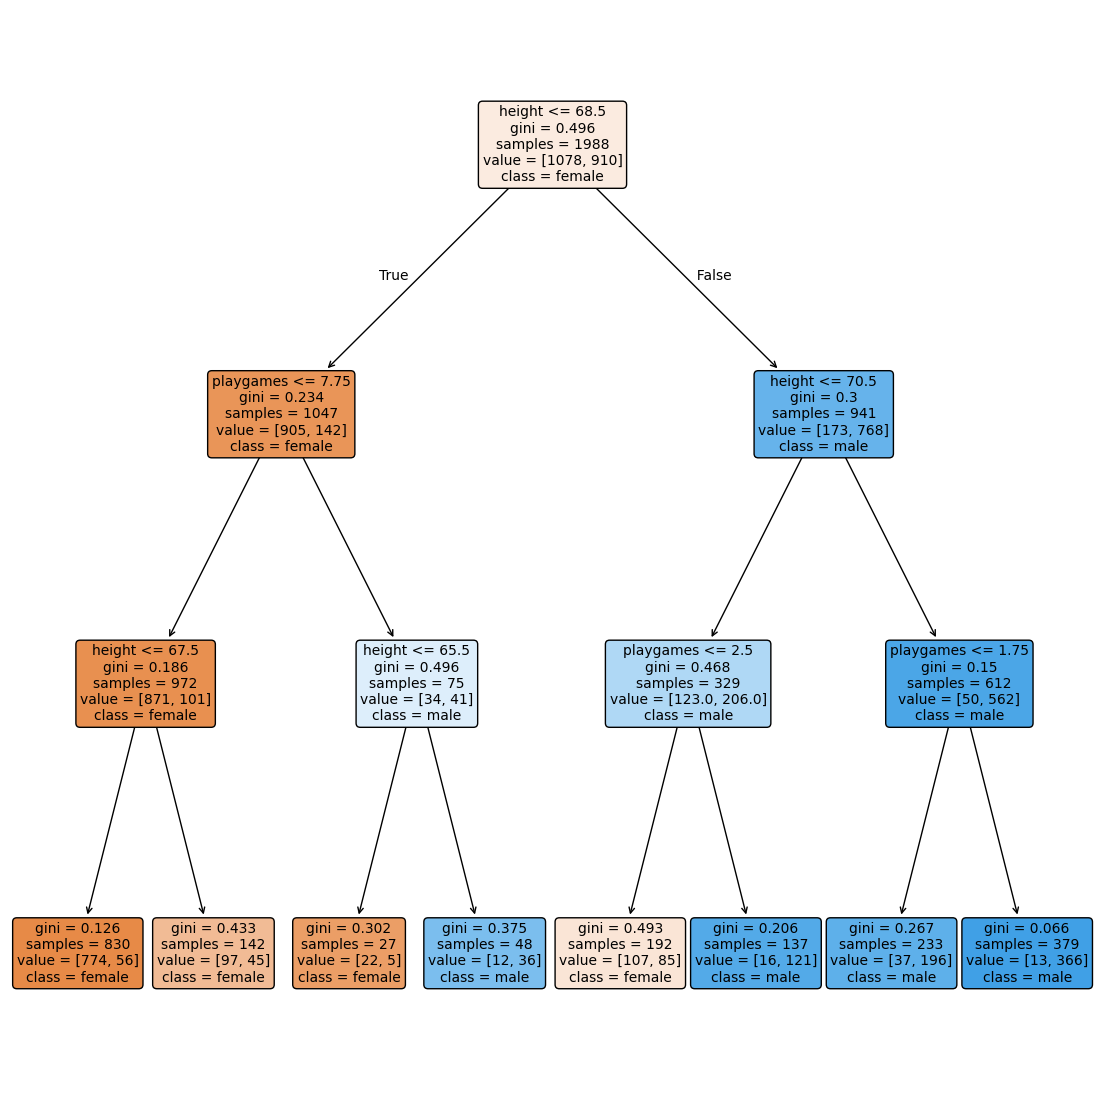

In [82]:
# Option 1 (Recommended Option) - Using `tree.plot_tree`

# clf = your classifier
# fig, ax = plt.subplots(figsize=(14, 14))
# tree.plot_tree(clf, fontsize=10, feature_names=<Names of columns>);
fig, ax = plt.subplots(figsize=(14, 14))

tree.plot_tree(
    clf,
    fontsize=10,
    feature_names=vectorizer.get_feature_names_out(),
    class_names=label_encoder.classes_,
    filled=True,
    rounded=True,
    ax=ax
)

plt.show()

In [ ]:
# Option 2 - Using GraphViz. Visualization is prettier, but additional setup may be required if running on your local machine (although no setup required on Colab)

from IPython.display import Image
import pydotplus
import pydot
from six import StringIO

# clf = your classifier
# dotfile = StringIO()
# tree.export_graphviz(clf, out_file=dotfile,
#                       feature_names=<Names of columns>,
#                           class_names=['Female', 'Male'],
#                           filled=True, rounded=True,
#                           special_characters=True)
# graph = pydotplus.graph_from_dot_data(dotfile.getvalue())
# Image(graph.create_png())


In [ ]:
# YOUR CODE HERE
raise NotImplementedError()

---
## Bonus Question (2 points, auto graded)
For each of your leaf nodes, specify the percentage of 'female' rows in that node (out of the total number of rows at that node)


In [83]:
# The value set in the variable must be array
ratios = 0 # Replace 0 with the actual value

# YOUR CODE HERE
leaf_ratios = []

for node in range(clf.tree_.node_count):
    is_leaf = (
        clf.tree_.children_left[node] == -1 and
        clf.tree_.children_right[node] == -1
    )

    if is_leaf:
        class_values = clf.tree_.value[node][0]
        female_ratio = class_values[0] / class_values.sum()
        leaf_ratios.append(female_ratio)

ratios = np.array(leaf_ratios)

print(ratios)
print(ratios * 100)  # percentages


[0.93253012 0.68309859 0.81481481 0.25       0.55729167 0.11678832
 0.15879828 0.03430079]
[93.25301205 68.30985915 81.48148148 25.         55.72916667 11.67883212
 15.87982833  3.43007916]


In [84]:
# This is cell for grading, do not edit
print(ratios)

[0.93253012 0.68309859 0.81481481 0.25       0.55729167 0.11678832
 0.15879828 0.03430079]


*ⓒ Prof. Zachary Pardos, 2026*